In [1]:
# !pip install uv

In [2]:
try:
    import lightgbm as lgb
except:
    !uv pip install -q lightgbm
    import lightgbm as lgb

lgb.__version__

'4.6.0'

In [3]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from time import time, sleep
from tqdm import tqdm

## -- Machine Learning --
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split, cross_val_score

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [5]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e8/"
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/jimarahman/smartphone-usage-and-addiction-analysis-dataset/"
    orig = pd.read_csv(ORIG_PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## ----------------------------------------------------------------------------------------

ID      = "id"
TARGET  = "addicted_label"
OBJECTS = train.select_dtypes(include=["object", "category"]).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (691369, 14)
Test shape: (296302, 13)
Orig shape: (7500, 16)

Total Numerical: 9
Total Categorical: 3
Total base features: 12


In [7]:
display(train.head())
train.info()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


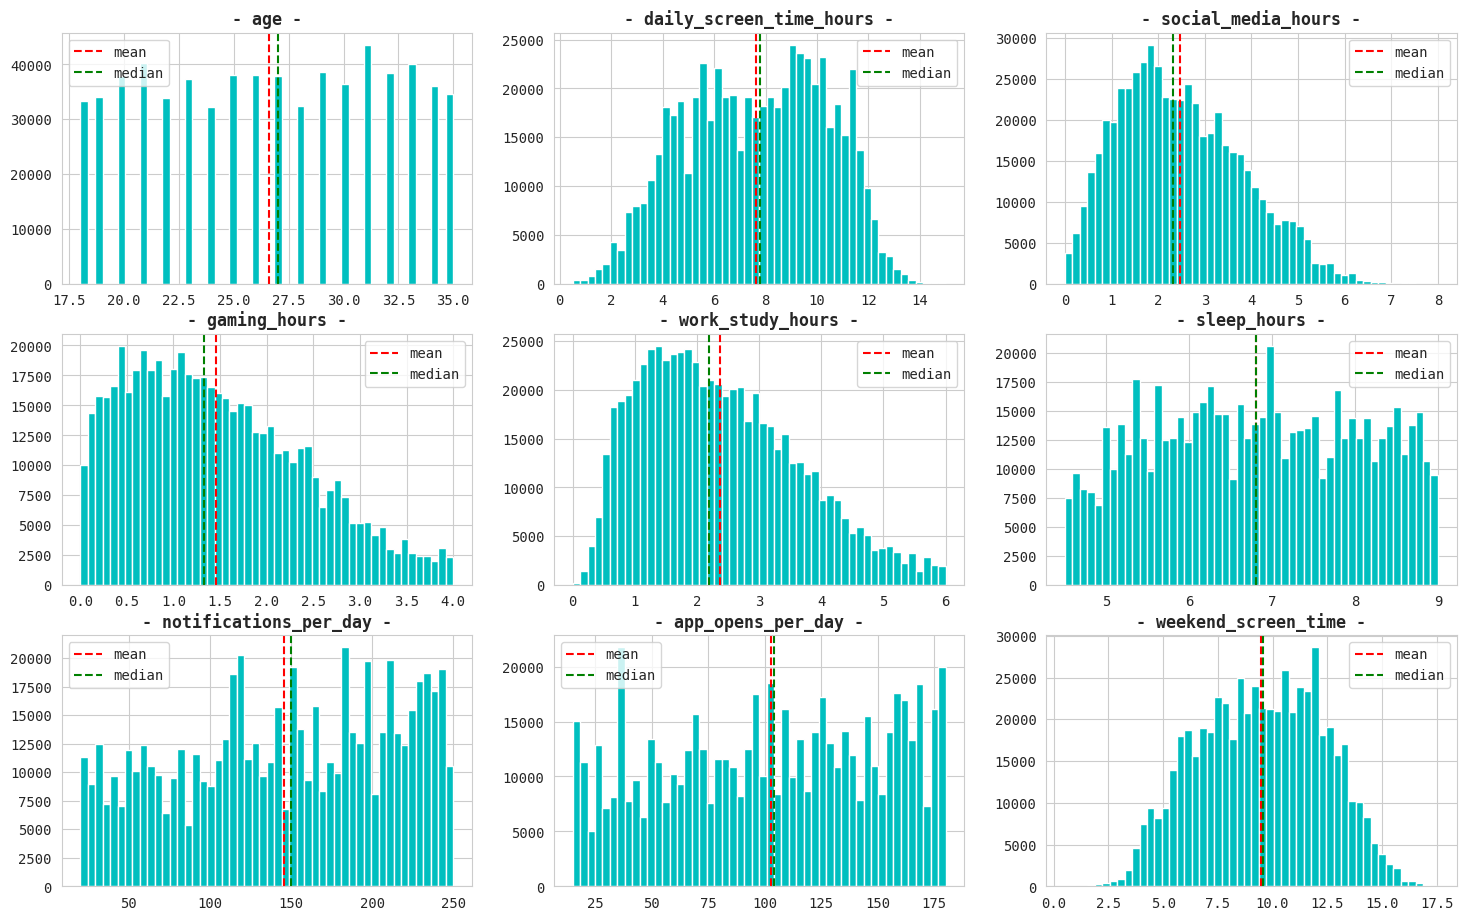

In [9]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'- {col} -', fontweight='semibold')
    plt.legend()
    
plt.show()

In [10]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIG_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIG_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIG_UNIQUE, index=['Orig']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.T.sort_values(by="Train").style.background_gradient(subset="Train")

,Train,Orig,Test
academic_work_impact,2,2,2
gender,3,3,3
stress_level,3,3,3
age,18,18,18
app_opens_per_day,166,166,166
notifications_per_day,231,231,231
gaming_hours,401,401,401
sleep_hours,451,451,451
work_study_hours,600,551,601
social_media_hours,721,551,703


## FEATURE ENGINEERING

In [11]:
ROUNDS = []
FLOORS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [12]:
# for col in NUMS:
#     # print(f"\nRounding... ", end='')
#     # for r in range(-2, 3):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')

#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nDIGITS... ", end='')
#     for d in range(-3, 3):
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
#         # orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#         ## -- Drop constant features --
#         if train[d_n].nunique() < digit_thresh:
#             DROP_COLS.append(d_n)
#         else:
#             DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [100]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [13]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
# orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [14]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Series([], dtype: float64)

In [15]:
def apply_feature_engineering(df1, num_features_, cat_features_):
    df = df1.copy()

    num_to_cat = []
    for col in num_features_:
        cat_name = f"{col}_cat"
        df[cat_name] = df[col].fillna('NaN').astype(str)
        num_to_cat.append(cat_name)

    for c in num_features_:
        for i in [0, 1]:
            df[f"{c}_round{i}"] = df[c].round(i)

    social  = df['social_media_hours']
    gaming  = df['gaming_hours']
    work    = df['work_study_hours']
    daily   = df['daily_screen_time_hours']
    sleep   = df['sleep_hours']
    weekend = df['weekend_screen_time']
    opens   = df['app_opens_per_day']
    notifications = df['notifications_per_day']

    df['total_breakdown_hours'] = social.fillna(0) + gaming.fillna(0) + work.fillna(0)
    df['social_ratio'] = social / (daily + 1e-5)
    df['gaming_ratio'] = gaming / (daily + 1e-5)
    df['work_ratio'] = work / (daily + 1e-5)
    df['unaccounted_screen_time'] = daily - df['total_breakdown_hours']
    df['screen_to_sleep_ratio'] = daily / (sleep + 1e-5)
    df['weekend_vs_daily_ratio'] = weekend / (daily + 1e-5)
    df['app_opens_per_hour'] = opens / (daily + 1e-5)
    df['notifications_per_hour'] = notifications / (daily + 1e-5)

    COMP = ['social_media_hours', 'gaming_hours', 'work_study_hours']
    n_missing_components = df[COMP].isna().sum(axis=1)
    missing_daily = daily.isna()
    known_component_sum = df[COMP].sum(axis=1, min_count=1)
    slack = daily - known_component_sum
    daily_missing_with_components = missing_daily & (n_missing_components == 0)
    one_component_missing = (~missing_daily) & (n_missing_components == 1)
    all_screen_known = (~missing_daily) & (n_missing_components == 0)

    df['ci_daily_lb'] = np.where(daily_missing_with_components, known_component_sum, np.nan)
    df['ci_missing_comp_ub'] = np.where(one_component_missing, slack, np.nan)
    df['ci_missing_comp_mid'] = np.where(one_component_missing, np.clip(slack / 2, 0, None), np.nan)
    df['ci_interval_width'] = np.where(one_component_missing, slack, np.nan)
    df['ci_slack_exact'] = np.where(all_screen_known, slack, np.nan)
    df['ci_case'] = np.select([daily_missing_with_components, one_component_missing], [1.0, 2.0], default=0.0).astype('float32')
    df['ci_n_missing'] = (missing_daily.astype('int8') + n_missing_components).astype('float32')

    df['missing_count'] = df[num_features_+cat_features_].isna().sum(axis=1).astype('int8')

    drop = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
    if drop:
        df.drop(drop, axis=1, inplace=True)

    fe_cols = [c for c in df.columns if c not in BASE]

    if ID in fe_cols:
        fe_cols.remove(ID)
    if TARGET in fe_cols:
        fe_cols.remove(TARGET)

    return df, fe_cols

train, FE_COLS  = apply_feature_engineering(train, NUMS, CATS)
test, _ = apply_feature_engineering(test, NUMS, CATS)
orig, _ = apply_feature_engineering(orig, NUMS, CATS)

new_cats = [c for c in FE_COLS if c.endswith("_cat")]

# new_cats = ["missing_count"]
# new_cats.extend([
#     c for c in FE_COLS
#     if "_round" in c
#     or c.endswith("_cat")
#     or c.startswith("ci_")
# ])

new_nums = [c for c in FE_COLS if c not in new_cats]

# CATS.extend(new_cats)
# NUMS.extend(new_nums)

display(train[new_cats+new_nums].head())

train[FE_COLS].nunique().sort_values()

,age_cat,daily_screen_time_hours_cat,social_media_hours_cat,gaming_hours_cat,work_study_hours_cat,sleep_hours_cat,notifications_per_day_cat,app_opens_per_day_cat,weekend_screen_time_cat,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1
4,26.0,11.2,1.87,2.81,1.95,5.25,NaN,NaN,13.39,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2


ci_case                                3
gaming_hours_round0                    5
ci_n_missing                           5
sleep_hours_round0                     6
work_study_hours_round0                7
social_media_hours_round0              9
missing_count                         12
daily_screen_time_hours_round0        16
age_round1                            18
weekend_screen_time_round0            18
age_round0                            18
age_cat                               19
gaming_hours_round1                   41
sleep_hours_round1                    46
work_study_hours_round1               61
social_media_hours_round1             81
daily_screen_time_hours_round1       146
app_opens_per_day_round0             166
app_opens_per_day_round1             166
weekend_screen_time_round1           167
app_opens_per_day_cat                167
notifications_per_day_round1         231
notifications_per_day_round0         231
notifications_per_day_cat            232
gaming_hours_cat

In [16]:
# def add_frequency_condition(df1, cols, thresh=5): 
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [17]:
# ## -- Frequency encoding --
# FREQ_COLS = []

# print(f"\nCreating frequencies... ", end="")
# for col in NUMS:
#     freq = pd.concat([train[col], test[col], orig[col]]).value_counts(dropna=False, normalize=True) #
#     n = f"{col}_FREQ"
#     print(n+", ", end="")
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype("float32")
#     FREQ_COLS.append(n)

# print(f"\n✓ Total frequency features: {len(FREQ_COLS)}")

# train[NUMS+FREQ_COLS]

In [18]:
INTER = []

inter_cols = ["missing_count", "ci_n_missing", "ci_case"]
combo_2_list = list(itertools.combinations(inter_cols + CATS, 2))

for c1, c2 in tqdm(combo_2_list, desc='Pairwise'):
    n_col = f"Bi_{c1}-|-{c2}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
    # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
    INTER.append(n_col)

# for c1, c2, c3 in tqdm(list(itertools.combinations(CATS, 3)), desc='Triplewise'):
#     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# for c1, c2 in tqdm(list(itertools.product(CATS, DIGITS)), desc='One-to-Many'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

print(f"Total Interaction Features: {len(INTER)}")

Pairwise: 100%|██████████| 15/15 [00:08<00:00,  1.70it/s]

Total Interaction Features: 15


In [19]:
# ## -- Cyclic encoding --

# for df in [train, test]:
#     for p in [8, 12, 24]:
#         df[f"sleep_hours_sin_{p}"] = np.sin(2 * np.pi * df["sleep_hours"] / p).astype("float32")
#         df[f"sleep_hours_cos_{p}"] = np.cos(2 * np.pi * df["sleep_hours"] / p).astype("float32")

In [20]:
# train["orig_preds"] = np.load(
#     "/kaggle/input/datasets/sylvesterdalmeida/ps6e8-original-prediction/ag_best_addicted_label_train.npy"
# )

# test["orig_preds"]  = np.load(
#     "/kaggle/input/datasets/sylvesterdalmeida/ps6e8-original-prediction/ag_best_addicted_label_test.npy"
# )

In [21]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [22]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [23]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    df: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return df.copy()

    if aggs is None or len(aggs) == 0:
        return df.copy()

    X_df = df.copy()

    orig_cols = []
    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc="original_augmenting"):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_df = X_df.merge(map_df, on=col, how='left')

            orig_cols.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in orig_cols:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_df = fill_conditionally(X_df)

    return X_df, orig_cols

print("-- Data augment function ready! --")

-- Data augment function ready! --


In [24]:
# ## -- "mean", "median", "count", "std", "skew", "nunique", "max", "min"
# orig_aggs = ["median", "count", "std"]

# train, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     features=BASE,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# test, _ = orig_TE_data_propagate(
#     orig,
#     test,
#     features=BASE,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# train[orig_cols][:10].T

In [25]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Total Features:", len(FEATURES))

combined = pd.concat([train, test, orig])
## ------------------------------------------------------------
## -- Duplicate Nums as Cats --
# CATS_2 = []
# for c in tqdm(NUMS, title="nums_to_cats"):
#     n = f"{c}_cat"
#     combined[n] = combined[c].copy()
#     CATS_2.append(n)
## ------------------------------------------------------------
## -- Factorize CATS --
for c in tqdm(CATS+INTER, desc="factorize_cats"): # +new_cats
    combined[c] = combined[c].factorize()[0]

for c in tqdm(CATS, desc="categorize_cats"):
    combined[c] = combined[c].astype("category")

train = combined.iloc[:len(train)][FEATURES+[TARGET]]
test  = combined.iloc[len(train):len(train)+len(test)][FEATURES]
orig  = combined.iloc[len(train)+len(test):]

del combined
print("Label encoding complete!")

train

Total Features: 71


categorize_cats: 100%|██████████| 3/3 [00:00<00:00, 82.66it/s]


Label encoding complete!


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_cat,daily_screen_time_hours_cat,social_media_hours_cat,gaming_hours_cat,work_study_hours_cat,sleep_hours_cat,notifications_per_day_cat,app_opens_per_day_cat,weekend_screen_time_cat,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,Bi_missing_count-|-ci_n_missing,Bi_missing_count-|-ci_case,Bi_missing_count-|-gender,Bi_missing_count-|-stress_level,Bi_missing_count-|-academic_work_impact,Bi_ci_n_missing-|-ci_case,Bi_ci_n_missing-|-gender,Bi_ci_n_missing-|-stress_level,Bi_ci_n_missing-|-academic_work_impact,Bi_ci_case-|-gender,Bi_ci_case-|-stress_level,Bi_ci_case-|-academic_work_impact,Bi_gender-|-stress_level,Bi_gender-|-academic_work_impact,Bi_stress_level-|-academic_work_impact,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,2,2,2,2,2,2,2,1,1,2,2,2,2,2,1,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,3,3,3,3,3,3,3,2,2,3,2,3,3,3,2,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,26.0,11.2,1.87,2.81,1.95,5.25,NaN,NaN,13.39,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2.0,4,4,1,1,1,3,4,3,3,2,3,4,1,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,0,-1,0,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,22.0,22.0,11.0,10.8,3.0,3.2,2.0,1.6,2.0,1.6,8.0,7.7,86.0,86.0,94.0,94.0,13.0,12.9,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.719843,7.977729,NaN,NaN,NaN,NaN,4.31,0.0,0.0,1.0,3,3,0,13,0,3,5,10,3,4,9,4,9,0,9,1.0
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,1,2,0,20.0,3.45,1.86,0.89,0.3,6.59,221.0,42.0,8.47,20.0,20.0,3.0,3.4,2.0,1.9,1.0,0.9,0.0,0.3,7.0,6.6,221.0,221.0,42.0,42.0,8.0,8.5,3.05,0.539129,0.257970,0.086956,0.40,0.523520,2.455065,12.173878,64.057785,NaN,NaN,NaN,NaN,0.40,0.0,0.0,0.0,5,5,7,4,4,

In [26]:
# plt.figure(figsize=(18, 18))
# sns.heatmap(train.corr("spearman"), annot=True, center=0, cbar=False, fmt=".2f")
# plt.tight_layout()
# plt.show()

# ML TRAINING

In [27]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kfold,
               cat_cols=None, use_original=False, early_stop=100, print_every=200):
    
    print(f"\n===== Starting CV: {model_name} | {get_system_info()} =====")
    t0 = time()
    
    feats = features.copy()
    oof_preds   = np.zeros(len(train_df))
    test_preds  = np.zeros(len(test_df))
    
    fold_scores = []
    feat_importances = []

    # Handle optional original table aggregations securely if flags enable them
    if use_original and "orig_TE_data_propagate" in globals():
        # "mean" for bagging | ("mean", "count", "std", "skew") for goss
        aggs_ = ["mean", "count", "std", "skew"] 

        X_tr, orig_cols = orig_TE_data_propagate(
            orig, train_data, target=TARGET, features=BASE, aggs=aggs_, #fill_nan=True
        )
        x_test, _ = orig_TE_data_propagate(
            orig, test, target=TARGET, features=BASE, aggs=aggs_, #fill_nan=True
        )
        feats.extend(orig_cols)
        X = X_tr[feats]
        y = X_tr[target].astype("int8")
        X_ts = x_test[feats]
    else:
        X = train_data[feats]
        y = train_data[target].astype("int8")
        X_ts = test[feats]

    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\n+++++ FOLD {idx}/{kfold.n_splits}", end=" | ")

        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = X_ts.copy()

        # ## -- OPTION A: Concatenate original data --
        # if use_original:
            # X_train = pd.concat([X_train, orig[features]], ignore_index=True)
            # y_train = pd.concat([y_train, orig[target]], ignore_index=True)
            # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # cme_cols = ROUNDS
        # print(f"CategoryMeanEncoding: {len(cme_cols)} | ", end='')
        # cme = CategoryMeanTransformer(cat_cols=cme_cols)
        # X_train = cme.fit_transform(X_train, y_train)
        # X_valid = cme.transform(X_valid)
        # X_test  = cme.transform(X_test)

        te_enc  = TargetEncoder(new_cats+INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        X_train = te_enc.fit_transform(X_train, y_train)
        X_valid = te_enc.transform(X_valid)
        X_test  = te_enc.transform(X_test)
    
        # combined = pd.concat([X_train, X_valid, X_test])
        # for c in cat_cols:
        #     combined[c] = combined[c].factorize()[0]
        #     combined[c] = combined[c].astype('category')
        # X_train = combined.iloc[:len(X_train)]
        # X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        # X_test  = combined.iloc[len(X_train)+len(X_valid):]

        print(f"shape: {X_train.shape}")
        if idx == 1:
            display(X_train.head())

        callbacks = [
            lgb.early_stopping(early_stop),
            lgb.log_evaluation(print_every),
            # lgb.record_evaluation(eval_result),
        ]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_train, y_train,
            # eval_X=X_valid, eval_y=y_valid,
            eval_set=[(X_train, y_train), (X_valid, y_valid)],
            eval_names=["train", "valid"],
            # eval_class_weight=get_class_weights(y_train, y_train),
            callbacks=callbacks,
        )

        feat_importances.append(model.feature_importances_.ravel())

        ## -- Predict on val and test sets --
        oof_preds[val_idx] = model.predict_proba(X_valid)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / kfold.n_splits

        ## -- Calculate fold score --
        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"{CFG['YELLOW']} • FOLD {idx} AUC: {fold_score:.6f}{CFG['RESET']}")
        # ----------------------------------------------------------------------------------------

    # ## -- Average test predictions --
    # test_preds /= kfold.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name} | {X_train.shape}")
    print("==================================================")
    for i, s in enumerate(fold_scores, 1):
        print(f" • Fold {i} AUC: {s:.6f}")

    ## -- Calculate out-of-fold Score --
    oof_score = np.round(roc_auc_score(y, oof_preds), 6)

    print("-------------------------------------------------|")
    print(f"OOF score: {oof_score}")
    print(f"AVG score: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f"{(time()-t0)/60:.2f} mins\n")

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_score,
        'model': model,
        'importances': feat_importances,
        'val_data': [X_valid, y_valid],
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


In [28]:
VER = f"lgb_fe83"

all_predictions = {}

MULTI_SEEDS = [42, 777, 1234, 24611, 0]
ALL_CATS = CATS 

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN = True
x_sample, x_sample2 = train_test_split(train, train_size=0.5, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_cat,daily_screen_time_hours_cat,social_media_hours_cat,gaming_hours_cat,work_study_hours_cat,sleep_hours_cat,notifications_per_day_cat,app_opens_per_day_cat,weekend_screen_time_cat,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,Bi_missing_count-|-ci_n_missing,Bi_missing_count-|-ci_case,Bi_missing_count-|-gender,Bi_missing_count-|-stress_level,Bi_missing_count-|-academic_work_impact,Bi_ci_n_missing-|-ci_case,Bi_ci_n_missing-|-gender,Bi_ci_n_missing-|-stress_level,Bi_ci_n_missing-|-academic_work_impact,Bi_ci_case-|-gender,Bi_ci_case-|-stress_level,Bi_ci_case-|-academic_work_impact,Bi_gender-|-stress_level,Bi_gender-|-academic_work_impact,Bi_stress_level-|-academic_work_impact,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,2,2,2,2,2,2,2,1,1,2,2,2,2,2,1,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,3,3,3,3,3,3,3,2,2,3,2,3,3,3,2,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,26.0,11.2,1.87,2.81,1.95,5.25,NaN,NaN,13.39,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2.0,4,4,1,1,1,3,4,3,3,2,3,4,1,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,0,-1,0,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,22.0,22.0,11.0,10.8,3.0,3.2,2.0,1.6,2.0,1.6,8.0,7.7,86.0,86.0,94.0,94.0,13.0,12.9,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.719843,7.977729,NaN,NaN,NaN,NaN,4.31,0.0,0.0,1.0,3,3,0,13,0,3,5,10,3,4,9,4,9,0,9,1.0
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,1,2,0,20.0,3.45,1.86,0.89,0.3,6.59,221.0,42.0,8.47,20.0,20.0,3.0,3.4,2.0,1.9,1.0,0.9,0.0,0.3,7.0,6.6,221.0,221.0,42.0,42.0,8.0,8.5,3.05,0.539129,0.257970,0.086956,0.40,0.523520,2.455065,12.173878,64.057785,NaN,NaN,NaN,NaN,0.40,0.0,0.0,0.0,5,5,7,4,4,

## TEST TRAINER

#### Summary (Order) Checklist
---

* Step 1: Fix `learning_rate` to `0.05` + use `early_stopping` (`~50`) + set `n_estimators` to high value `1000+`.
* Step 2: Tune `num_leaves` + `max_depth` together.
* Step 3: (If GOSS): Tune `feature_fraction`, then `top_rate` + `other_rate`.
* Step 3: (If Bagging): Tune `bagging_fraction` + `bagging_freq`, then `feature_fraction`.
* Step 4: Tune `min_data_in_leaf`.
* Step 5: Tune `lambda_l1` + `lambda_l2`.
* Step 6: Drop `learning_rate` to `~0.03` for final training.

In [29]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# # if all_predictions:
# #     all_predictions.clear()
    
# # [np.round(c, 2) for c in np.linspace(0.0, 1.0, 6)]
# OUTER_ = [0]
# INNER_ = [0]
# p_name = ["l1", 'l2']

# for i, outer in enumerate(OUTER_):
#     for j, inner in enumerate(INNER_):
#         print(f" >>> {p_name[0]} {i+1}/{len(OUTER_)} of {p_name[1]} {j+1}/{len(INNER_)} <<<")
#         PARAMS = {
#             # 'boosting': 'dart',
#             # ---------------------------------
#             'data_sample_strategy': "goss",
#             'top_rate': 0.6,
#             'other_rate': 0.1,
#             # ---------------------------------
#             'objective': "binary", 
#             'metric': 'auc',
#             # 'max_leaves': outer,
#             'n_estimators': 10_000,
#             # 'learning_rate': outer,
#             # 'max_depth': outer,
#             # 'bagging_fraction': outer, # disable for 'goss'
#             'feature_fraction': 0.4,
#             # 'feature_fraction_bynode': outer, # disable for 'goss'
#             # 'bagging_freq': outer,         # disable for 'goss'
#             'reg_alpha': 0.1,
#             'reg_lambda': 0.5,
#             'min_data_in_leaf': 170,
#             # 'max_bins': outer,
#             # 'max_cat_to_onehot': 9,
#             'importance_type': 'gain',
#             'random_state': CFG['SEED'],
#             'verbosity': -1,
#             'n_jobs': -1,
#             # 'device': 'gpu' if torch.cuda.is_available() else 'cpu',
#         }

#         n = VER + f"{p_name[0]}={OUTER_[i]}__{p_name[1]}={INNER_[j]}"
#         all_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=PARAMS,
#             train_df=train_data,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kfold=skf,
#             cat_cols=ALL_CATS,
#             # use_original=True,
#             # early_stop=100,
#             print_every=500, 
#         )

# print(f"\n===== ☑️ Training complete! {len(all_predictions)} model(s) =====\n")

In [30]:
# ================================================== 
# 5-FOLD CV: bagging_TE_original
# ==================================================
#  • Fold 1 AUC: 0.959084
#  • Fold 2 AUC: 0.959253
#  • Fold 3 AUC: 0.959783
#  • Fold 4 AUC: 0.960263
#  • Fold 5 AUC: 0.959141
# -------------------------------------------------|
# OOF score: 0.959503
# AVG score: 0.959505 ± 0.000453
# -------------------------------------------------|
# 1.46 mins

# ==================================================
# 5-FOLD CV: lgb_base
# ==================================================
#  • Fold 1 AUC: 0.954049
#  • Fold 2 AUC: 0.954552
#  • Fold 3 AUC: 0.955426
#  • Fold 4 AUC: 0.955882
#  • Fold 5 AUC: 0.954825
# -------------------------------------------------|
# OOF score: 0.954944
# AVG score: 0.954947 ± 0.000645
# -------------------------------------------------|
# 0.78 mins

In [31]:
# ==================================================
# 5-FOLD CV: GOSS
# ==================================================
# top_r=0.5, other=0.1, col=0.25, max_leaves=_, min_leaf=270, l1=10.0, l2=5.0, lr=_
# ==================================================
#  • Fold 1 AUC: 0.966435
#  • Fold 2 AUC: 0.967311
#  • Fold 3 AUC: 0.967529
#  • Fold 4 AUC: 0.967842
#  • Fold 5 AUC: 0.966993
# -------------------------------------------------|
# OOF score: 0.967223
# AVG score: 0.967222 ± 0.000481
# -------------------------------------------------|
# 5.51 mins

# 5-FOLD CV: BAGGING
# ==================================================
# max_leaves=_, sub=0.8, col=0.8, min_leaf=100, l1=10.0, l2=3.0, lr=_
# ==================================================
# 5-FOLD CV: lgb_l1=10__l2=3
# ==================================================
#  • Fold 1 AUC: 0.966320
#  • Fold 2 AUC: 0.967067
#  • Fold 3 AUC: 0.967396
#  • Fold 4 AUC: 0.967768
#  • Fold 5 AUC: 0.966543
# -------------------------------------------------|
# OOF score: 0.967026
# AVG score: 0.967028 ± 0.000533
# -------------------------------------------------|
# 4.67 mins

In [32]:
# all_scores = {}

# for i, (k, v) in enumerate(all_predictions.items()):
#     for x, y in v.items():
#         if x == "score":
#             all_scores[k] = y

# plt.figure(figsize=(16, 6))
# ax1 = sns.lineplot([*all_scores.values()], marker="s")

# y_add = 1e-6

# for i, s1 in enumerate([*all_scores.values()]):
#     ax1.text(float(i), s1+y_add, s1, ha="center", va="baseline")

# # plt.ylim((0.94, 0.955))
# plt.legend(loc="best")
# plt.xticks(range(len(all_scores)), [*all_scores.keys()], rotation=90)
# plt.title("LightGBM scores", fontdict={"weight": "semibold", "size": 15})

# plt.tight_layout() 
# plt.show()

In [33]:
# all_importances = {}
# all_val_data = {}

# for i, (k, v) in enumerate(all_predictions.items()):
#     for x, y in v.items():
#         if x == "importances":
#             all_importances[k] = np.mean(y, axis=0)
#         elif x == "val_data":
#             all_val_data[k] = y # -> [0] select X_val, [1] select y_valid

# top_n = 25

# for i, (m, fi) in enumerate(all_importances.items()):
#     fi_df = pd.DataFrame({
#         "feature": all_val_data[m][0].columns,
#         "importance": fi,
#     }).sort_values(by="importance", ascending=False).reset_index(drop=True)
    
#     plt.figure(figsize=(15, len(all_importances)*7))
#     plt.subplot(len(all_importances), 1, i+1)
#     sns.barplot(data=fi_df.head(top_n), x="importance", y="feature")
#     plt.title(f"{m}: Avg. {CFG['FOLDS']}-Fold Feature Importances", fontweight="semibold")

#     plt.tight_layout() 
#     plt.show()

#     print()

### OPTUNA SEARCH

In [34]:
# try:
#     import optuna
# except:
#     !uv pip install optuna
#     import optuna

In [35]:
# def objective(trial):
#     params = {
#         # -------------------------------------------------
#         # "bagging_fraction": trial.suggest_float("subsample", 0.6, 1.0, step=0.05),
#         "feature_fraction": trial.suggest_float("colsample", 0.3, 0.9, step=0.05),
#         # -------------------------------------------------
#         'data_sample_strategy': "goss",
#         "top_rate": trial.suggest_float("top_rate", 0.4, 0.7, step=0.05),
#         "other_rate": trial.suggest_float("other_rate", 0.1, 0.3, step=0.05),
#         # -------------------------------------------------
#         "max_leaves": trial.suggest_int("max_leaves", 31, 127),
#         # "max_depth": 0,
#         # "max_depth": trial.suggest_int("max_depth", 3, 10),
#         # -------------------------------------------------
#         # Core Tree Booster Parameters
#         "min_data_in_leaf": trial.suggest_int("min_leaf", 1, 100),
#         # "max_bins": trial.suggest_int("max_bins", 255, 1024, step=128),
#         # Regularization Parameters (Staves off overfitting)
#         "reg_alpha": trial.suggest_float("alpha", 1e-5, 15.0, log=True),
#         "reg_lambda": trial.suggest_float("lambda", 1e-5, 15.0, log=True),

#         "learning_rate": 0.05,
#         # "learning_rate": trial.suggest_float("lr", 0.05),

#         # Structural Settings
#         "n_estimators": 20_000,
#         'objective': "binary",
#         'metric': "auc",
#         "random_state": CFG['SEED'],
#         "n_jobs": -1,
#         "device": "cuda" if torch.cuda.is_available() else "cpu",
#     }

#     n = "Optuna"

#     all_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=params,
#         train_df=train_data,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kfold=skf,
#         cat_cols=ALL_CATS,
#         use_original=True,
#         early_stop=100,
#         print_every=1000,
#     )
#     return all_predictions[n]["score"]

# print("Optuna search ready!")

# # # 3. Create the study and run optimization
# # if __name__ == "__main__":
# #     # TPE Sampler (Bayesian Optimization) is used by default
# #     study = optuna.create_study(direction="maximize")

# #     # Run optimization for 50 trials
# #     study.optimize(objective, n_trials=50, show_progress_bar=True)

# #     # Print out results
# #     print("\n--- Optimization Complete ---")
# #     print(f"Best Trial ROC-AUC Score: {study.best_value:.4f}")
# #     print("Best Hyperparameters:")
# #     for key, value in study.best_params.items():
# #         print(f"  {key}: {value}")

# #     # 4. Train the final model using the absolute best parameters
# #     best_model = xgb.XGBClassifier(**study.best_params, tree_method="hist", random_state=42)
# #     best_model.fit(X, y)


In [36]:
# # 3. Create the study and run optimization
# study = optuna.create_study(direction="maximize", study_name="LightGBM_Search")

# # Run optimization for 50 trials
# study.optimize(objective, n_trials=30, timeout=3600*2, show_progress_bar=True)

In [37]:
# print("\n--- Optimization Complete ---")
# print(f"Best Trial ROC-AUC Score: {study.best_value:.6f}")
# print("Best Hyperparameters:")
# study.best_params

# # Default learning_rate: 0.05 --

# # --- (BAGGING) ---
# # Best Trial ROC-AUC Score: 0.967905
# # Best Hyperparameters:
# # {'subsample': 0.6,
# #  'colsample': 0.6000000000000001,
# #  'max_leaves': 81,
# #  'min_leaf': 8,
# #  'alpha': 2.2480062510638112,
# #  'lambda': 7.37798445754072e-05}

# # --- (GOSS) ---
# # Best Trial ROC-AUC Score: 0.968094
# # Best Hyperparameters:
# # {'colsample': 0.45,
# #  'top_rate': 0.55,
# #  'other_rate': 0.2,
# #  'max_leaves': 83,
# #  'min_leaf': 10,
# #  'alpha': 6.152263203981487,
# #  'lambda': 0.006907123629972495}

In [38]:
# ## -- Visualize parameter importance
# optuna.visualization.plot_param_importances(study).show()

In [39]:
# ## -- Otimization history across trials
# optuna.visualization.plot_slice(study).show()

In [40]:
# ## -- Optimization history --
# optuna.visualization.plot_optimization_history(study).show()

## MAIN TRAINER

In [41]:
LR = 0.01
# L2_REG = 2.5
EARLY_STOP   = 200
PRINT_STEPS  = 1000
USE_ORIGINAL = True

LR

0.01

In [42]:
## ==================== BOOST
# use -> orig_te(mean) + apply_feat + te(_cat) + INTER()
# # --- (BAGGING) ---
# # Best Trial ROC-AUC Score: 0.967905
# # Best Hyperparameters:
# # {'subsample': 0.6,
# #  'colsample': 0.6000000000000001,
# #  'max_leaves': 81,
# #  'min_leaf': 8,
# #  'alpha': 2.2480062510638112,
# #  'lambda': 7.37798445754072e-05}

bag_params = {
    # 'boosting': 'dart',
    # ----------------------------
    # 'is_unbalanced': True,
    # 'max_depth': 8,
    'objective': "binary",
    'metric': "auc",
    'learning_rate': LR,
    'n_estimators': 30_000,
    'max_leaves': 80,
    'bagging_fraction': 0.8,
    'feature_fraction': 0.6,
    # 'feature_fraction_bynode': 0.6,
    # 'bagging_freq': 7,
    # 'max_bins': 600,
    'min_data_in_leaf': 80,
    'reg_alpha': 5.0,
    'reg_lambda': 10.0,
    # 'max_cat_to_onehot': 9,
    'random_state': CFG['SEED'] + 1,
    'importace_type': "gain",
    'verbosity': -1,
    'n_jobs': -1,
    'device': "gpu" if torch.cuda.is_available() else "cpu",
}

n = VER + "bag"

# for value in [12, 15]:
#     bag_params['max_depth'] = value
#     n = f"lgb_bag_" + str(value)
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=bag_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_original=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS,
)


===== Starting CV: lgb_fe83bag | CPU: 4 =====


original_augmenting: 100%|██████████| 12/12 [00:10<00:00,  1.13it/s]



+++++ FOLD 1/5 | shape: (553095, 119)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,oTE_age_mean,oTE_age_count,oTE_age_std,oTE_age_skew,oTE_daily_screen_time_hours_mean,oTE_daily_screen_time_hours_count,oTE_daily_screen_time_hours_std,oTE_daily_screen_time_hours_skew,oTE_social_media_hours_mean,oTE_social_media_hours_count,oTE_social_media_hours_std,oTE_social_media_hours_skew,oTE_gaming_hours_mean,oTE_gaming_hours_count,oTE_gaming_hours_std,oTE_gaming_hours_skew,oTE_work_study_hours_mean,oTE_work_study_hours_count,oTE_work_study_hours_std,oTE_work_study_hours_skew,oTE_sleep_hours_mean,oTE_sleep_hours_count,oTE_sleep_hours_std,oTE_sleep_hours_skew,oTE_notifications_per_day_mean,oTE_notifications_per_day_count,oTE_notifications_per_day_std,oTE_notifications_per_day_skew,oTE_app_opens_per_day_mean,oTE_app_opens_per_day_count,oTE_app_opens_per_day_std,oTE_app_opens_per_day_skew,oTE_weekend_screen_time_mean,oTE_weekend_screen_time_count,oTE_weekend_screen_time_std,oTE_weekend_screen_time_skew,oTE_gender_mean,oTE_gender_count,oTE_gender_std,oTE_gender_skew,oTE_stress_level_mean,oTE_stress_level_count,oTE_stress_level_std,oTE_stress_level_skew,oTE_academic_work_impact_mean,oTE_academic_work_impact_count,oTE_academic_work_impact_std,oTE_academic_work_impact_skew,TE_age_cat_mean,TE_daily_screen_time_hours_cat_mean,TE_social_media_hours_cat_mean,TE_gaming_hours_cat_mean,TE_work_study_hours_cat_mean,TE_sleep_hours_cat_mean,TE_notifications_per_day_cat_mean,TE_app_opens_per_day_cat_mean,TE_weekend_screen_time_cat_mean,TE_Bi_missing_count-|-ci_n_missing_mean,TE_Bi_missing_count-|-ci_case_mean,TE_Bi_missing_count-|-gender_mean,TE_Bi_missing_count-|-stress_level_mean,TE_Bi_missing_count-|-academic_work_impact_mean,TE_Bi_ci_n_missing-|-ci_case_mean,TE_Bi_ci_n_missing-|-gender_mean,TE_Bi_ci_n_missing-|-stress_level_mean,TE_Bi_ci_n_missing-|-academic_work_impact_mean,TE_Bi_ci_case-|-gender_mean,TE_Bi_ci_case-|-stress_level_mean,TE_Bi_ci_case-|-academic_work_impact_mean,TE_Bi_gender-|-stress_level_mean,TE_Bi_gender-|-academic_work_impact_mean,TE_Bi_stress_level-|-academic_work_impact_mean
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.752660,376.0,0.432041,-1.175863,NaN,NaN,NaN,NaN,0.571429,14.0,0.513553,-0.324537,0.700000,20.0,0.470162,-0.945300,0.750000,20.0,0.444262,-1.250514,0.869565,23.0,0.344350,-2.350873,0.694444,36.0,0.467177,-0.881390,0.851064,47.0,0.359875,-2.037747,0.555556,9.0,0.527046,-2.710524e-01,0.722288,2553,0.447959,-0.993225,0.707838,2437,0.454850,-0.914623,0.707701,3753,0.45488,-0.913697,0.774182,0.711779,0.665823,0.661971,0.746836,0.751920,0.547685,0.945214,0.702710,0.706643,0.704296,0.724374,0.705428,0.710841,0.709904,0.723480,0.704494,0.708827,0.726253,0.711059,0.710931,0.719297,0.723586,0.707809
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.712500,400.0,0.453163,-0.942564,0.333333,

Training until validation scores don't improve for 200 rounds
[1000]	train's auc: 0.967836	valid's auc: 0.965578
[2000]	train's auc: 0.97011	valid's auc: 0.966858
[3000]	train's auc: 0.971454	valid's auc: 0.967165
[4000]	train's auc: 0.972617	valid's auc: 0.967311
[5000]	train's auc: 0.973698	valid's auc: 0.967421
[6000]	train's auc: 0.974709	valid's auc: 0.967487
[7000]	train's auc: 0.975653	valid's auc: 0.967532
[8000]	train's auc: 0.976566	valid's auc: 0.96757
[9000]	train's auc: 0.977444	valid's auc: 0.967597
[10000]	train's auc: 0.9783	valid's auc: 0.967619
Early stopping, best iteration is:
[10574]	train's auc: 0.978772	valid's auc: 0.967628
 • FOLD 1 AUC: 0.967628

+++++ FOLD 2/5 | shape: (553095, 119)
Training until validation scores don't improve for 200 rounds
[1000]	train's auc: 0.967584	valid's auc: 0.966297
[2000]	train's auc: 0.969932	valid's auc: 0.967667
[3000]	train's auc: 0.971281	valid's auc: 0.967962
[4000]	train's auc: 0.972443	valid's auc: 0.968118
[5000]	train's 

In [43]:
# ==================================================
# 5-FOLD CV: lgb_fe12_bag | (553095, 83)
# ==================================================
#  • Fold 1 AUC: 0.966237
#  • Fold 2 AUC: 0.966872
#  • Fold 3 AUC: 0.966929
#  • Fold 4 AUC: 0.967303
#  • Fold 5 AUC: 0.966800
# -------------------------------------------------|
# OOF score: 0.966805
# AVG score: 0.966828 ± 0.000343
# -------------------------------------------------|
# 9.50 mins

In [44]:
## ==================== GOSS 
# use -> orig_te(mean, count, std, skew) + FREQ + apply_feat + te(_cat)
# # --- (GOSS) ---
# # Best Trial ROC-AUC Score: 0.968094
# # Best Hyperparameters:
# # {'colsample': 0.45,
# #  'top_rate': 0.55,
# #  'other_rate': 0.2,
# #  'max_leaves': 83,
# #  'min_leaf': 10,
# #  'alpha': 6.152263203981487,
# #  'lambda': 0.006907123629972495}

goss_params = {
    # 'boosting': 'dart',
    # ---------------------------------
    'data_sample_strategy': "goss",
    'top_rate': 0.6,
    'other_rate': 0.15,
    # ---------------------------------
    # 'is_unbalanced': True,
    # 'max_depth': 6,
    'objective': "binary",
    'metric': "auc",
    'learning_rate': LR,
    'n_estimators': 30_000,
    'max_leaves': 83,
    'feature_fraction': 0.4,
    'min_data_in_leaf': 100,
    'reg_alpha': 5.0,
    'reg_lambda': 10.0,
    # 'max_bins': 254,
    # 'max_cat_to_onehot': 9,
    'importace_type': "gain",
    'random_state': CFG['SEED'] + 2,
    'verbosity': -1,
    'n_jobs': -1,
    # 'device': "gpu" if torch.cuda.is_available() else "cpu",
}

n = VER + "goss"

# for value in [100, 200, 300]:
#     goss_params['n_estimators'] = value
#     n = f"lgb_goss_" + str(value)
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=goss_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_original=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS,
)


===== Starting CV: lgb_fe83goss | CPU: 4 =====


original_augmenting: 100%|██████████| 12/12 [00:09<00:00,  1.26it/s]



+++++ FOLD 1/5 | shape: (553095, 119)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,oTE_age_mean,oTE_age_count,oTE_age_std,oTE_age_skew,oTE_daily_screen_time_hours_mean,oTE_daily_screen_time_hours_count,oTE_daily_screen_time_hours_std,oTE_daily_screen_time_hours_skew,oTE_social_media_hours_mean,oTE_social_media_hours_count,oTE_social_media_hours_std,oTE_social_media_hours_skew,oTE_gaming_hours_mean,oTE_gaming_hours_count,oTE_gaming_hours_std,oTE_gaming_hours_skew,oTE_work_study_hours_mean,oTE_work_study_hours_count,oTE_work_study_hours_std,oTE_work_study_hours_skew,oTE_sleep_hours_mean,oTE_sleep_hours_count,oTE_sleep_hours_std,oTE_sleep_hours_skew,oTE_notifications_per_day_mean,oTE_notifications_per_day_count,oTE_notifications_per_day_std,oTE_notifications_per_day_skew,oTE_app_opens_per_day_mean,oTE_app_opens_per_day_count,oTE_app_opens_per_day_std,oTE_app_opens_per_day_skew,oTE_weekend_screen_time_mean,oTE_weekend_screen_time_count,oTE_weekend_screen_time_std,oTE_weekend_screen_time_skew,oTE_gender_mean,oTE_gender_count,oTE_gender_std,oTE_gender_skew,oTE_stress_level_mean,oTE_stress_level_count,oTE_stress_level_std,oTE_stress_level_skew,oTE_academic_work_impact_mean,oTE_academic_work_impact_count,oTE_academic_work_impact_std,oTE_academic_work_impact_skew,TE_age_cat_mean,TE_daily_screen_time_hours_cat_mean,TE_social_media_hours_cat_mean,TE_gaming_hours_cat_mean,TE_work_study_hours_cat_mean,TE_sleep_hours_cat_mean,TE_notifications_per_day_cat_mean,TE_app_opens_per_day_cat_mean,TE_weekend_screen_time_cat_mean,TE_Bi_missing_count-|-ci_n_missing_mean,TE_Bi_missing_count-|-ci_case_mean,TE_Bi_missing_count-|-gender_mean,TE_Bi_missing_count-|-stress_level_mean,TE_Bi_missing_count-|-academic_work_impact_mean,TE_Bi_ci_n_missing-|-ci_case_mean,TE_Bi_ci_n_missing-|-gender_mean,TE_Bi_ci_n_missing-|-stress_level_mean,TE_Bi_ci_n_missing-|-academic_work_impact_mean,TE_Bi_ci_case-|-gender_mean,TE_Bi_ci_case-|-stress_level_mean,TE_Bi_ci_case-|-academic_work_impact_mean,TE_Bi_gender-|-stress_level_mean,TE_Bi_gender-|-academic_work_impact_mean,TE_Bi_stress_level-|-academic_work_impact_mean
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.752660,376.0,0.432041,-1.175863,NaN,NaN,NaN,NaN,0.571429,14.0,0.513553,-0.324537,0.700000,20.0,0.470162,-0.945300,0.750000,20.0,0.444262,-1.250514,0.869565,23.0,0.344350,-2.350873,0.694444,36.0,0.467177,-0.881390,0.851064,47.0,0.359875,-2.037747,0.555556,9.0,0.527046,-2.710524e-01,0.722288,2553,0.447959,-0.993225,0.707838,2437,0.454850,-0.914623,0.707701,3753,0.45488,-0.913697,0.774182,0.711779,0.665823,0.661971,0.746836,0.751920,0.547685,0.945214,0.702710,0.706643,0.704296,0.724374,0.705428,0.710841,0.709904,0.723480,0.704494,0.708827,0.726253,0.711059,0.710931,0.719297,0.723586,0.707809
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.712500,400.0,0.453163,-0.942564,0.333333,

Training until validation scores don't improve for 200 rounds
[1000]	train's auc: 0.967565	valid's auc: 0.965424
[2000]	train's auc: 0.969988	valid's auc: 0.966939
[3000]	train's auc: 0.971317	valid's auc: 0.967262
[4000]	train's auc: 0.972436	valid's auc: 0.967407
[5000]	train's auc: 0.973482	valid's auc: 0.96751
[6000]	train's auc: 0.974466	valid's auc: 0.967584
[7000]	train's auc: 0.975387	valid's auc: 0.967633
[8000]	train's auc: 0.976272	valid's auc: 0.967669
[9000]	train's auc: 0.977118	valid's auc: 0.967698
[10000]	train's auc: 0.977929	valid's auc: 0.967725
[11000]	train's auc: 0.978713	valid's auc: 0.967742
Early stopping, best iteration is:
[11370]	train's auc: 0.978993	valid's auc: 0.967745
 • FOLD 1 AUC: 0.967745

+++++ FOLD 2/5 | shape: (553095, 119)
Training until validation scores don't improve for 200 rounds
[1000]	train's auc: 0.967331	valid's auc: 0.966173
[2000]	train's auc: 0.969822	valid's auc: 0.967749
[3000]	train's auc: 0.971128	valid's auc: 0.968056
[4000]	trai

In [45]:
# ==================================================
# 5-FOLD CV: lgb_fe12_goss
# ================================================== 
#  • Fold 1 AUC: 0.965444
#  • Fold 2 AUC: 0.966208
#  • Fold 3 AUC: 0.966353
#  • Fold 4 AUC: 0.966650
#  • Fold 5 AUC: 0.965771
# -------------------------------------------------|
# OOF score: 0.966083
# AVG score: 0.966085 ± 0.000428
# -------------------------------------------------|
# 2.99 mins

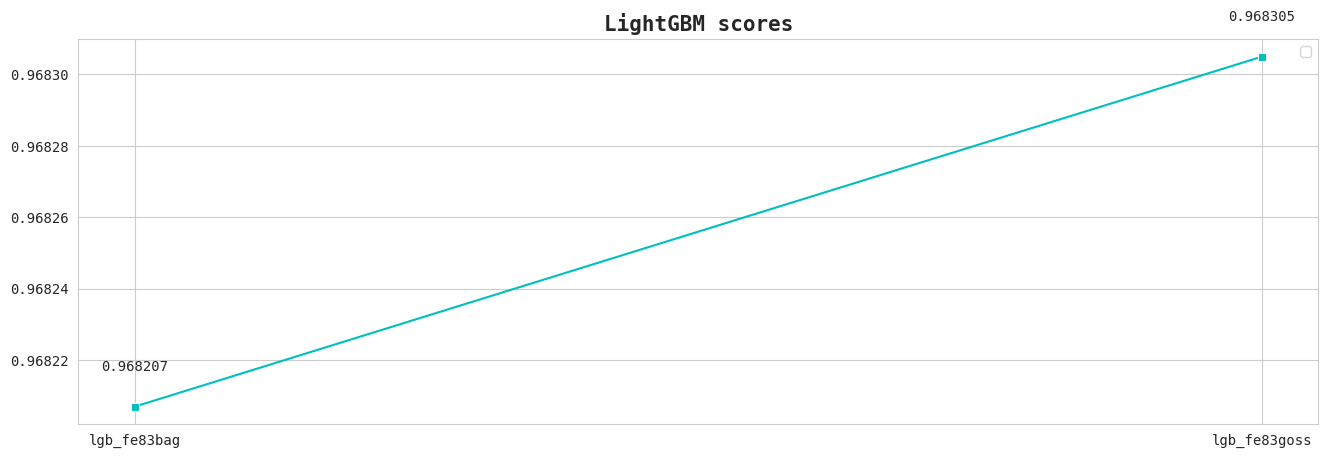

In [46]:
all_scores = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == "score":
            all_scores[k] = y

plt.figure(figsize=(16, 5))
ax1 = sns.lineplot([*all_scores.values()], marker="s")

y_add = 1e-5

for i, s1 in enumerate([*all_scores.values()]):
    ax1.text(float(i), s1+y_add, s1, ha="center", va="baseline")

# plt.ylim((0.94, 0.955))
plt.legend(loc="best")
plt.xticks(range(len(all_scores)), [*all_scores.keys()], rotation=0)
plt.title("LightGBM scores", fontdict={"weight": "semibold", "size": 15})

# plt.tight_layout() 
plt.show()

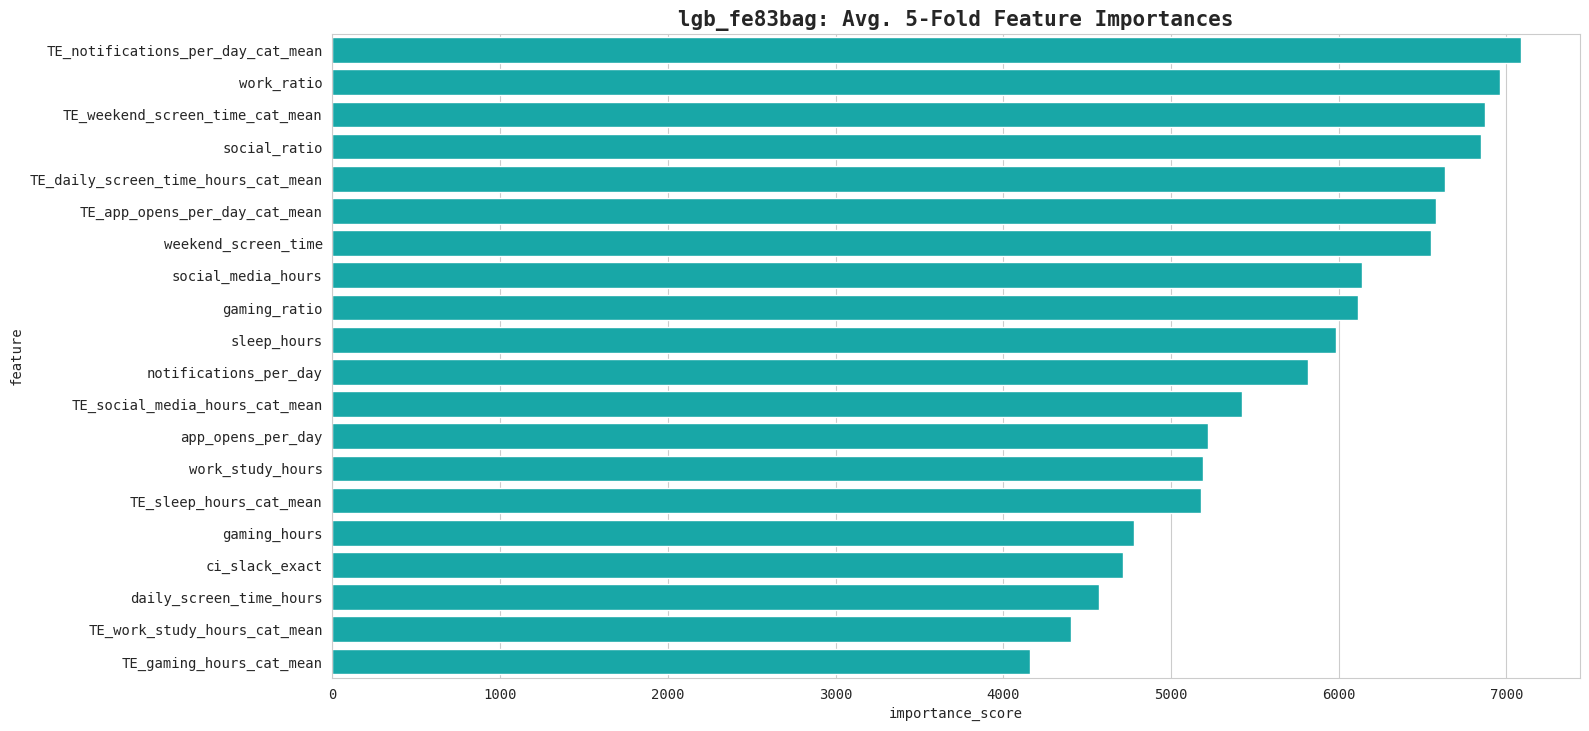

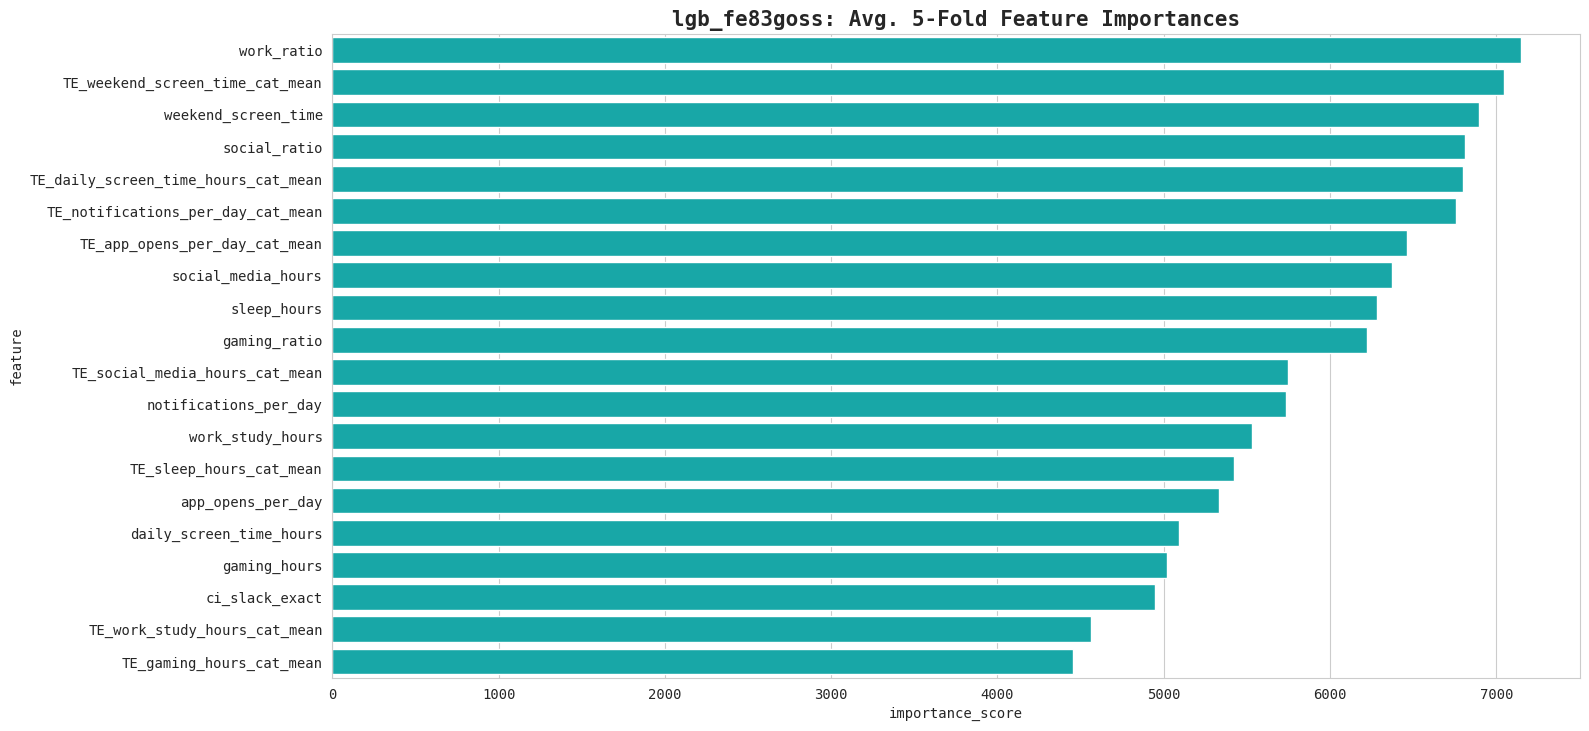

In [47]:
all_importances = {}
all_val_data = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == "importances":
            all_importances[k] = np.mean(y, axis=0)
        elif x == "val_data":
            all_val_data[k] = y # -> [0] select X_val, [1] select y_valid

top_n = 20

for i, (m, fi) in enumerate(all_importances.items()):
    fi_df = pd.DataFrame({
        "feature": all_val_data[m][0].columns,
        "importance_score": fi,
    }).sort_values(by="importance_score", ascending=False).reset_index(drop=True)
    
    plt.figure(figsize=(16, len(all_importances)*7))
    plt.subplot(len(all_importances), 1, i+1)
    sns.barplot(data=fi_df.head(top_n), x="importance_score", y="feature")
    plt.title(f"{m}: Avg. {CFG['FOLDS']}-Fold Feature Importances", fontsize=15, fontweight="semibold")

    plt.tight_layout() 
    plt.show()

    print()

lgb_fe83bag_968207 saved!


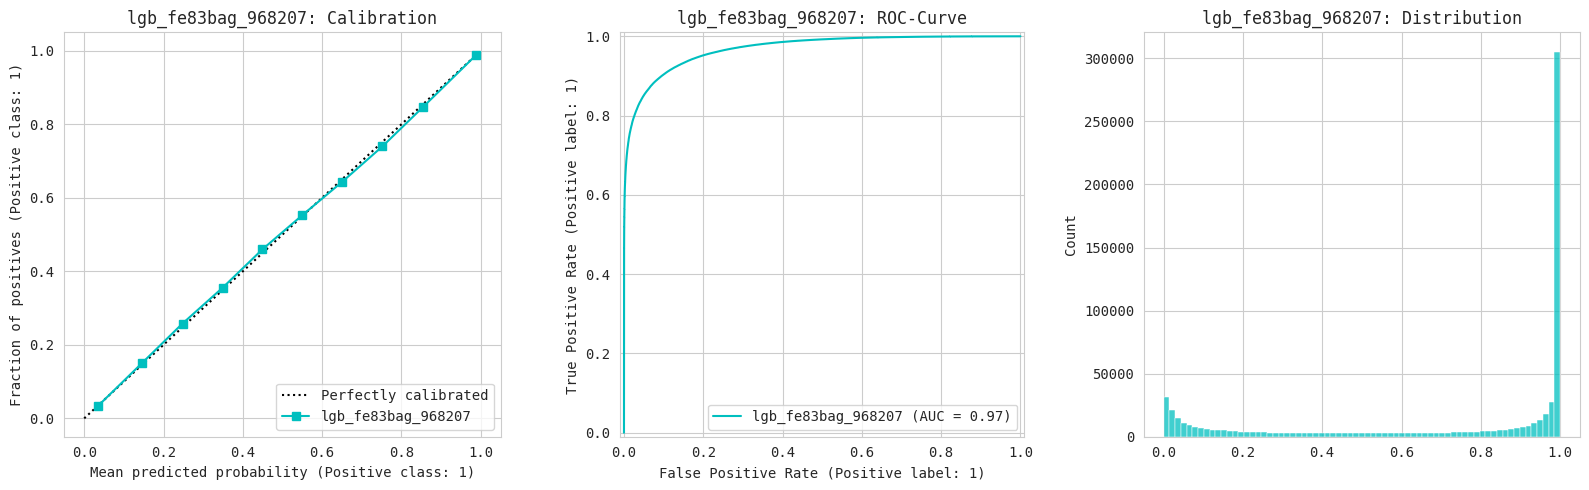


lgb_fe83goss_968305 saved!


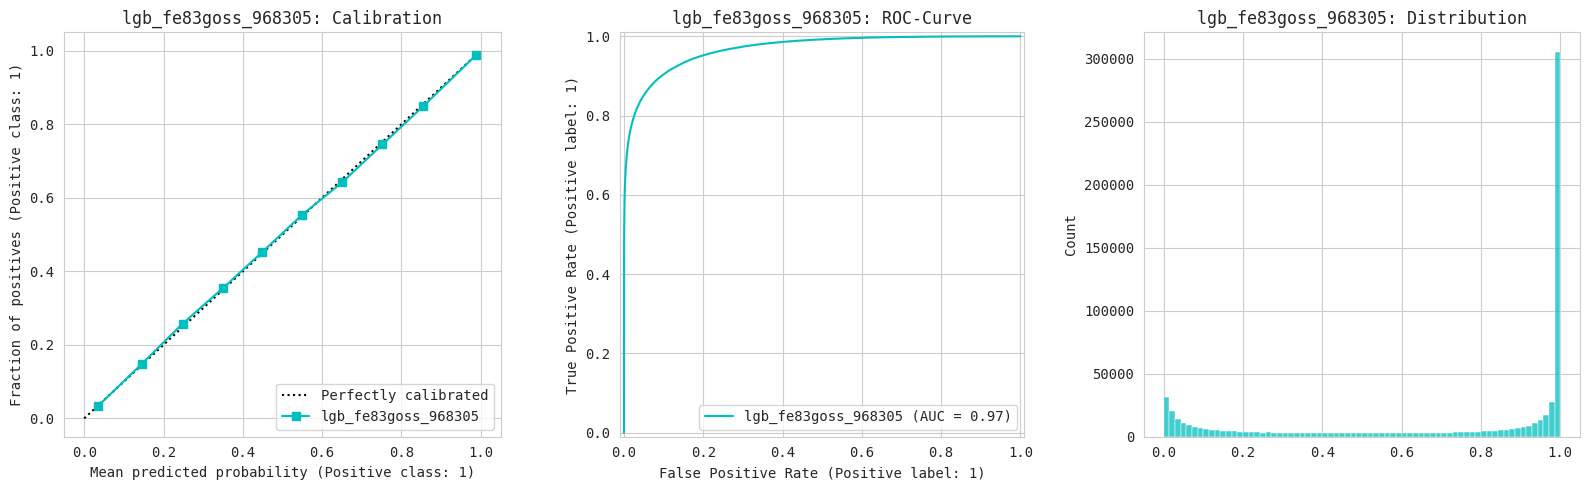

In [48]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, data_ in v.items():
        if key_ == "oof_preds":
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_data[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title(f"{n}: Calibration")

            RocCurveDisplay.from_predictions(train_data[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title(f"{n}: ROC-Curve")

            sns.histplot(data_, ax=axs[2])
            axs[2].set_title(f"{n}: Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [49]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submit[TARGET] = y
            submit.to_csv(f"submit_{n}.csv", index=False)
            print(f"{n} saved! {y.shape}")

            model_results[n] = y

lgb_fe83bag_968207 saved! (296302,)
lgb_fe83goss_968305 saved! (296302,)


In [50]:
pd.DataFrame(model_results)

,lgb_fe83bag_968207,lgb_fe83goss_968305
0,0.999539,0.999596
1,0.962628,0.964832
2,0.750469,0.771848
3,0.993494,0.994180
4,0.997709,0.997989
...,...,...
296297,0.999997,0.999998
296298,0.706665,0.731703
296299,0.199799,0.218906
296300,0.809543,0.821209


In [51]:
# !rm -r /kaggle/working